# Motor Insurance Risk & Claim Probability Analytics
## Data Cleaning & Feature Engineering (Python Layer)

### Objective

This notebook prepares the raw motor insurance dataset for enterprise-level business analytics.

The goals of this stage are:

- Inspect dataset structure
- Identify data quality issues
- Standardize column names
- Engineer business-relevant features
- Create risk segmentation variables
- Prepare processed dataset for SQL, Excel, and Dashboard layers

This forms the analytical foundation for risk-based business insights.

In [4]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve display readability
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Load Raw Dataset

The raw dataset is stored in the `data/raw/` directory.
We load it without modifying the original file to preserve data integrity.

In [7]:
# Load Raw Dataset

file_path = "../data/raw/insurance_claims_raw.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully.")
df.head()

Dataset Loaded Successfully.


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3000,1.2000,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2000,1.8000,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9000,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5000,0.2000,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2000,0.4000,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6000,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1000,1.0000,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0000,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


## Step 2: Initial Inspection

We evaluate:

- Dataset size
- Column names
- Data types
- Missing values
- Distribution of target variable

In [10]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns.tolist())

# Data Types and Non-Null Counts
print("\nData Info:")
df.info()

# Missing Values
print("\nMissing Values Per Column:")
print(df.isnull().sum())

Dataset Shape: (58592, 41)

Column Names:
['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            -------

## Step 3: Target Variable Analysis

The target variable is `claim_status`.

0 = No Claim  
1 = Claim Occurred  

We compute overall claim rate to understand dataset balance.

In [13]:
# Overall Claim Rate
claim_rate = df['claim_status'].mean()

print(f"Overall Claim Rate: {claim_rate:.4f}")

Overall Claim Rate: 0.0640


## Step 4: Standardize Column Names

We convert all column names to lowercase snake_case to ensure:

- SQL compatibility
- Professional schema discipline
- Consistent naming conventions

In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3000,1.2000,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2000,1.8000,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9000,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5000,0.2000,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2000,0.4000,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6000,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1000,1.0000,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0000,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


## Step 5: Feature Engineering

We will create:

- customer_age_band
- vehicle_age_band
- subscription_length_band
- risk_tier (based on claim behavior)
- region_claim_rate
- vehicle_segment_claim_rate

These engineered features enhance business interpretability.

In [19]:
# Customer Age Bands
df['customer_age_band'] = pd.cut(
    df['customer_age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# Vehicle Age Bands
df['vehicle_age_band'] = pd.cut(
    df['vehicle_age'],
    bins=[0, 2, 5, 10, 20],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
)

## Step 6: Region-Level Risk Index

We compute claim rate per region to identify high-risk geographies.

In [22]:
region_risk = (
    df.groupby('region_code')['claim_status']
    .mean()
    .reset_index()
    .rename(columns={'claim_status': 'region_claim_rate'})
)

df = df.merge(region_risk, on='region_code', how='left')

region_risk.head()

,region_code,region_claim_rate
0,C1,0.0518
1,C10,0.0469
2,C11,0.0594
3,C12,0.0548
4,C13,0.0570


## Step 7: Risk Tier Segmentation

We classify customers into:

- Low Risk
- Medium Risk
- High Risk

Based on region-level claim probability.

In [25]:
def assign_risk_tier(rate):
    if rate < 0.05:
        return "Low Risk"
    elif rate < 0.15:
        return "Medium Risk"
    else:
        return "High Risk"

df['risk_tier'] = df['region_claim_rate'].apply(assign_risk_tier)

df[['region_code', 'region_claim_rate', 'risk_tier']].head()

,region_code,region_claim_rate,risk_tier
0,C8,0.0699,Medium Risk
1,C2,0.0708,Medium Risk
2,C8,0.0699,Medium Risk
3,C10,0.0469,Low Risk
4,C13,0.0570,Medium Risk


## Step 8: Risk Distribution Visualization

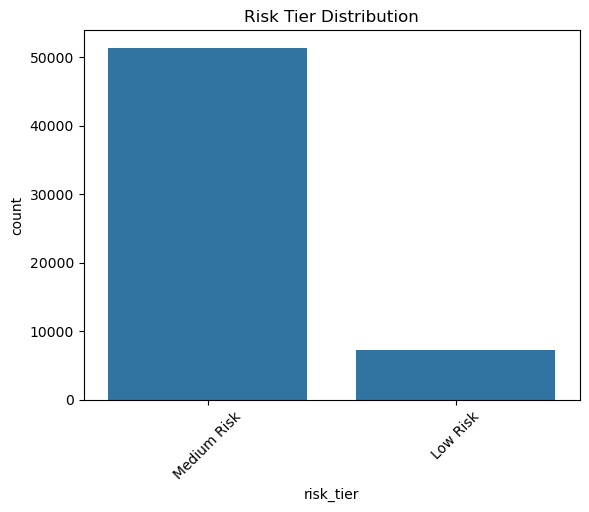

In [30]:
plt.figure()
sns.countplot(data=df, x='risk_tier')
plt.title("Risk Tier Distribution")
plt.xticks(rotation=45)
plt.show()

## Step 9: Export Processed Dataset

The processed dataset will be used in:

- SQL layer
- Excel reporting
- Dashboard layer

In [33]:
df.to_csv("../data/processed/insurance_claims_processed.csv", index=False)

print("Processed dataset exported successfully.")

Processed dataset exported successfully.
